In [19]:
import pyarrow.parquet as pq
import numpy as np
import pandas as pd

import plotly.graph_objs as go
import matplotlib.pyplot as plt

from tqdm import tqdm

import utility_functions as uf

In [3]:
path = "data/"

In [4]:
parqToRead='authorsPapersTopicsYearInstitutions.parquet'
# Read the parquet file filtering the lines where year=2005
table = pq.read_table(path+parqToRead, filters=[('year','=','2010')])
#table = pq.read_table(parqToRead)
# Convert to pandas DataFrame
df = table.to_pandas()

In [5]:
uf.id2name_country["RO"]

'Romania'

In [6]:
df_sample = df.iloc[:40]

In [7]:
country_list = df.country.drop_duplicates().sort_values().to_list()
country2idx = {c: i for i, c in enumerate(country_list)}

In [8]:
# (
#     df_sample
#     [["id", "country", "authors"]]
#     .groupby(["id", "country"], as_index=False)
#     .count()
#     .groupby("id")
#     .agg(list)
# )

In [9]:
dict_sample = (
    df
    [["id", "country", "authors"]]
    .assign(country_idx=lambda df: [country2idx[c] for c in df.country])
    .groupby(["id", "country_idx"], as_index=False)
    .authors
    .count()
    .groupby("id")
    .agg(list)
).to_dict("records")

In [10]:
# dict_sample

In [11]:
mx_collaborations = np.zeros((len(country_list), len(country_list)))
mx_collaborations_weighted = np.zeros((len(country_list), len(country_list)))

for article_dict in tqdm(dict_sample):
    idx = article_dict["country_idx"]
    mx_collaborations[np.ix_(idx, idx)] += 1
    weights = np.array(article_dict["authors"]) / sum(article_dict["authors"])

    mx_collaborations_weighted[np.ix_(idx, idx)] += weights[:, None]
# np.fill_diagonal(mx_collaborations, 0)

100%|██████████| 2424205/2424205 [00:20<00:00, 119332.73it/s]


In [12]:
mx_collaborations

array([[   3.,    0.,    0., ...,    0.,    0.,    0.],
       [   0., 1516.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,   36., ...,    0.,    0.,    0.],
       ...,
       [   0.,    0.,    0., ...,  185.,    5.,    0.],
       [   0.,    0.,    0., ...,    5.,  315.,    3.],
       [   0.,    0.,    0., ...,    0.,    3., 1002.]])

In [13]:
mx_collaborations_weighted.round(2)

array([[1.08000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 0.00000e+00],
       [0.00000e+00, 1.09703e+03, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 2.02500e+01, ..., 0.00000e+00,
        0.00000e+00, 0.00000e+00],
       ...,
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.04280e+02,
        1.25000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 7.10000e-01,
        2.19720e+02, 1.40000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.20000e+00, 7.22140e+02]])

In [14]:
mx_collaborations_weighted.sum(axis=0)

array([3.00000e+00, 1.51600e+03, 3.60000e+01, 1.60000e+01, 2.24000e+02,
       6.67000e+02, 6.30000e+01, 1.17630e+04, 8.00000e+00, 1.66800e+04,
       6.12940e+04, 6.00000e+00, 2.00000e+00, 6.25000e+02, 5.75000e+02,
       8.00000e+01, 2.13500e+03, 2.59900e+04, 2.32000e+02, 3.13900e+03,
       2.54000e+02, 1.88000e+02, 2.50000e+02, 4.20000e+01, 1.15000e+02,
       7.84000e+02, 6.49440e+04, 4.40000e+01, 2.00000e+01, 2.73000e+02,
       1.39600e+03, 1.90000e+01, 8.23970e+04, 9.40000e+01, 1.10000e+01,
       8.00000e+01, 2.89990e+04, 2.97000e+02, 9.12100e+03, 5.88000e+02,
       5.66541e+05, 1.17250e+04, 1.36500e+03, 3.00600e+03, 1.40000e+01,
       1.80000e+01, 1.28700e+03, 1.26270e+04, 1.34641e+05, 7.00000e+00,
       1.54340e+04, 9.00000e+00, 9.60000e+01, 2.80400e+03, 8.28000e+02,
       2.03700e+03, 8.54900e+03, 2.70000e+01, 6.61130e+04, 6.54000e+02,
       1.28070e+04, 1.20000e+02, 2.20000e+01, 1.00000e+01, 3.90000e+01,
       1.21503e+05, 7.00000e+01, 1.56317e+05, 6.10000e+01, 3.290

In [16]:
df_collaboration = pd.DataFrame(
    mx_collaborations,
    index=country_list,
    columns=country_list,
)
df_collaboration_weighted = pd.DataFrame(
    mx_collaborations_weighted,
    index=country_list,
    columns=country_list,
)

In [18]:
df_collaboration_weighted

,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VI,VN,VU,WS,XK,YE,ZA,ZM,ZW,None
AD,1.083333,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
AE,0.000000,1097.030656,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,1.246667,...,0.25,0.250000,0.0,0.0,0.0,0.111111,1.559649,0.000000,0.000000,0.000000
AF,0.000000,0.000000,20.254304,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
AG,0.000000,0.000000,0.000000,11.57619,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
AL,0.000000,0.000000,0.000000,0.00000,174.109127,0.000000,0.0,0.000000,0.0,0.785714,...,0.00,0.000000,0.0,0.0,0.0,0.000000,0.666667,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YE,0.000000,0.111111,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.200000,...,0.00,0.000000,0.0,0.0,0.0,188.686941,0.750000,0.000000,0.000000,0.000000
ZA,0.000000,0.892982,0.000000,0.00000,0.333333,0.072281,0.6,7.912849,0.0,12.662111,...,0.00,0.944444,0.0,0.0,0.0,1.000000,9569.692597,7.341820,13.809122,7.231804
ZM,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.119298,0.0,0.200000,...,0.00,0.000000,0.0,0.0,0.0,0.000000,6.677302,104.279595,1.250751,0.000000
ZW,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.00,0.000000,0.0,0.0,0.0,0.000000,13.661923,0.712506,219.722939,1.400000


(array([3.276e+03, 0.000e+00, 1.478e+03, 0.000e+00, 8.910e+02, 6.350e+02,
        8.120e+02, 5.250e+02, 3.480e+02, 5.440e+02, 3.770e+02, 3.720e+02,
        3.230e+02, 3.670e+02, 2.470e+02, 2.620e+02, 2.170e+02, 1.890e+02,
        1.500e+02, 1.530e+02, 1.620e+02, 1.170e+02, 7.800e+01, 9.100e+01,
        7.100e+01, 6.900e+01, 3.600e+01, 5.100e+01, 2.200e+01, 2.100e+01,
        3.400e+01, 1.800e+01, 8.000e+00, 8.000e+00, 7.000e+00, 1.400e+01,
        7.000e+00, 3.000e+00, 3.000e+00, 4.000e+00, 1.000e+00, 5.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([ 0.        ,  0.26576549,  0.53153097,  0.79729646,  1.06306195,
         1.32882743,  1.59459292,  1.86035841,  2.1261239 ,  2.39188938,
         2.65765487,  2.92342036,  3.18918584,  3.45495133,  3.72071682,
         3.9864823 ,  4.25224779,  4.51801328,  4.78377877,  5.04954425,
         5.31530974,  5.58107523,  5.84684071,  6.1126062 ,  6.37837169,
         6.

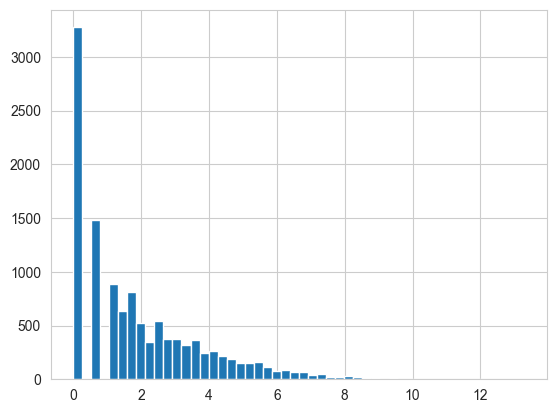

In [26]:
plt.hist(np.log(mx_collaborations[mx_collaborations > 0].flatten()), bins=50)

In [30]:
np.fill_diagonal(mx_collaborations, 0)

In [36]:
total_collab_articles = mx_collaborations.sum(axis=1)

In [39]:
df_country_collaboration = pd.DataFrame(total_collab_articles, index=country_list, columns=["total_articles"])
df_country_collaboration = df_country_collaboration[df_country_collaboration.index.notna()]


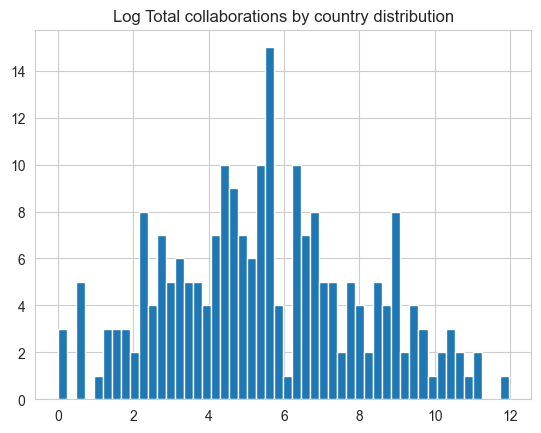

In [51]:
plt.hist(np.log(df_country_collaboration[df_country_collaboration > 0]), bins=50)
plt.title("Log Total collaborations by country distribution")
plt.show()

In [53]:
uf.gini(df_country_collaboration.total_articles)

0.8735672909373478

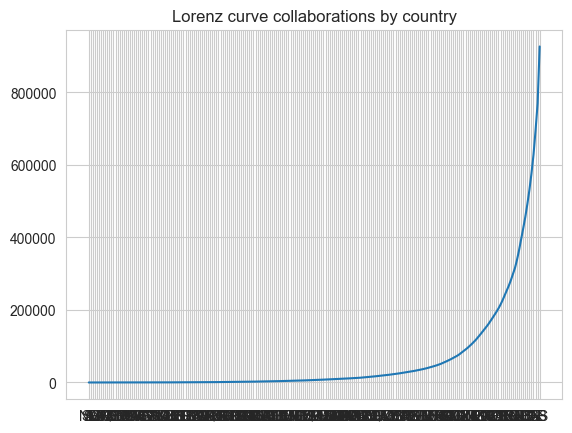

In [52]:
plt.plot(df_country_collaboration.sort_values("total_articles").cumsum())
plt.title("Lorenz curve collaborations by country")
plt.show()

(array([2.00e+00, 1.00e+00, 0.00e+00, 1.00e+00, 3.00e+00, 1.00e+00,
        1.20e+01, 1.00e+01, 5.00e+01, 1.04e+02, 2.32e+02, 3.05e+02,
        6.41e+02, 7.69e+02, 7.89e+02, 1.04e+03, 1.12e+03, 9.92e+02,
        8.30e+02, 7.77e+02, 6.53e+02, 6.02e+02, 5.34e+02, 4.93e+02,
        3.85e+02, 3.37e+02, 2.75e+02, 2.19e+02, 2.25e+02, 1.30e+02,
        1.12e+02, 9.20e+01, 6.90e+01, 4.60e+01, 4.20e+01, 3.10e+01,
        1.40e+01, 1.00e+01, 1.10e+01, 1.00e+01, 1.10e+01, 6.00e+00,
        4.00e+00, 1.00e+00, 6.00e+00, 2.00e+00, 2.00e+00, 0.00e+00,
        0.00e+00, 2.00e+00]),
 array([-6.93244789, -6.52950026, -6.12655264, -5.72360501, -5.32065738,
        -4.91770976, -4.51476213, -4.1118145 , -3.70886688, -3.30591925,
        -2.90297162, -2.500024  , -2.09707637, -1.69412874, -1.29118112,
        -0.88823349, -0.48528586, -0.08233824,  0.32060939,  0.72355702,
         1.12650464,  1.52945227,  1.9323999 ,  2.33534752,  2.73829515,
         3.14124278,  3.5441904 ,  3.94713803,  4.35008566,  

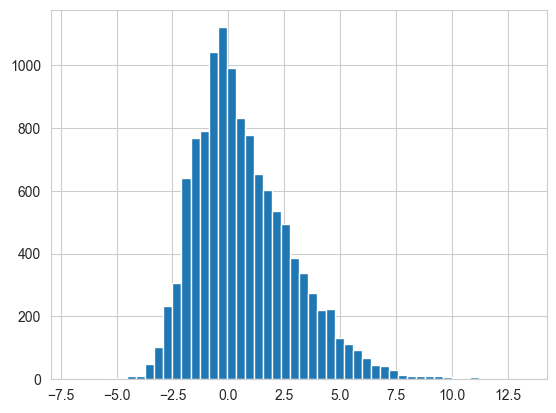

In [25]:
plt.hist(np.log(mx_collaborations_weighted[mx_collaborations_weighted > 0].flatten()), bins=50)

In [65]:
df_collaboration_weighted_norm = (
    df_collaboration_weighted
    .div(df_collaboration_weighted.sum(axis=0), axis=1)
)
df_collaboration_weighted_norm.sum(axis=0)

AD      1.0
AE      1.0
AF      1.0
AG      1.0
AL      1.0
       ... 
YE      1.0
ZA      1.0
ZM      1.0
ZW      1.0
None    1.0
Length: 221, dtype: float64

In [72]:
df_collaboration_weighted_norm = df_collaboration_weighted_norm.loc[df_collaboration_weighted_norm.index.notna(),
df_collaboration_weighted_norm.columns.notna()]

In [79]:
(map(str, df_collaboration_weighted_norm.columns))

In [80]:
x_labels = df_collaboration_weighted_norm.columns.astype(str).tolist()
y_labels = df_collaboration_weighted_norm.columns.astype(str).tolist()

customdata = np.empty(
    (len(y_labels), len(x_labels), 2),
    dtype=object
)

x_full = [uf.id2name_country[c] for c in (map(str, df_collaboration_weighted_norm.columns))]
y_full = [uf.id2name_country[c] for c in (map(str, df_collaboration_weighted_norm.columns))]

customdata[:, :, 0] = np.tile(x_full, (len(y_labels), 1))
customdata[:, :, 1] = np.tile(
    np.array(y_full).reshape(-1, 1),
    (1, len(x_labels))
)

# sub_list = list(map(str, uf.top_n_countries_by_articles(20)))

# country = "AX"
# top_n = 20
# sub_list = df_collaboration_weighted_norm.sort_values(country, ascending=True)[[country]].head(top_n).index.to_list()

# x_labels = [uf.id2name_country[c] for c in sub_list]
# y_labels = [uf.id2name_country[c] for c in sub_list]

fig = go.Figure(
    data=go.Heatmap(
        z=df_collaboration_weighted_norm.values,
        # z=df_collaboration_weighted_norm.loc[sub_list, sub_list].values,
        x=x_labels,
        y=y_labels,
        colorscale="Viridis",
        zmin=0,
        zmax=1.1,
        customdata=customdata,
        hovertemplate=(
            "<b>X - Country:</b> %{customdata[0]}<br>"
            "<b>Y - Country:</b> %{customdata[1]}<br>"
            "<b>Collaboration:</b> %{z:.3f}<br>"
            "<extra></extra>"
        )
    )
)

# Layout
fig.update_layout(
    title="Collaboration weights (sum by y = 1 -- all articles produced by country)",
    width=1000,
    height=20*len(y_labels),  # taller if more rows
    # height=40*len(y_labels),  # taller if more rows
    margin=dict(l=100, r=50, t=50, b=100),
    xaxis=dict(tickangle=45, automargin=True),
    yaxis=dict(autorange="reversed", automargin=True)  # keep top-to-bottom ordering
)

fig.show()